# Implementacao Completa v2: Classificacao Multiclasse (3 Classes)

Esta versao v2 preserva a estrutura do notebook original e aplica melhorias de modelagem e preprocessamento para elevar desempenho e robustez.

Melhorias aplicadas nesta versao:
- Preprocessamento por tipo de coluna (numericas e categoricas) com ColumnTransformer.
- One-hot encoding para atributos categoricos e padronizacao para atributos continuos.
- Selecao de atributos com VarianceThreshold e mutual_info_classif (SelectKBest).
- Arquitetura de rede mais profunda com BatchNormalization, L2 e Dropout.
- Treinamento com EarlyStopping e ReduceLROnPlateau.
- Avaliacao ampliada com accuracy, balanced accuracy, macro F1 e relatorio por classe.
- Bloco opcional de validacao cruzada estratificada para medir estabilidade.

Mapeamento da classe alvo (CLASSI_FIN):
- 0 = OUTRAS_DOENCAS
- 1 = CHIKUNGUNYA
- 2 = DENGUE

In [5]:
import warnings
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpu = tf.config.experimental.list_physical_devices("GPU")
print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Visible GPUs:", gpu)

I0000 00:00:1775940313.280467   93065 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775940313.335858   93065 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775940314.133051   93065 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
Built with CUDA: True
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1775940314.687587   93065 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## STEP 1: Load Data (Dataset Final)

In [6]:
# Caminho do dataset final processado.
DATA_PATH = "../data/data_set_final.csv"
TARGET_COL = "CLASSI_FIN"
CLASS_NAME_MAP = {0: "OUTRAS_DOENCAS", 1: "CHIKUNGUNYA", 2: "DENGUE"}

df = pd.read_csv(DATA_PATH)
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="raise").astype(int)

print("Dataset carregado com sucesso:", DATA_PATH)
print("Shape:", df.shape)
print("Colunas:", len(df.columns))
df.head()

Dataset carregado com sucesso: ../data/data_set_final.csv
Shape: (17172, 27)
Colunas: 27


,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ZONA,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,...,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DIAS,CLASSI_FIN
0,4022.0,0,5.0,1.0,3.0,1.0,1.0,1.0,2.0,2.0,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1,1
1,4020.0,1,6.0,4.0,1.0,1.0,1.0,1.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,6,1
2,4061.0,0,6.0,4.0,1.0,1.0,1.0,1.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,32,1
3,4046.0,1,6.0,4.0,1.0,1.0,1.0,1.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,1
4,4014.0,1,6.0,4.0,1.0,1.0,1.0,1.0,2.0,1.0,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,1


## STEP 2: Data Inspection and Quality Checks

In [7]:
print("Tipos de dados:")
print(df.dtypes)

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

print("\nLinhas duplicadas:", df.duplicated().sum())
print("Distribuicao da classe alvo:")
print(df[TARGET_COL].value_counts().sort_index())

# Resumo estatistico de todas as variaveis numericas.
df.describe().T

Tipos de dados:
NU_IDADE_N    float64
CS_SEXO         int64
CS_GESTANT    float64
CS_RACA       float64
CS_ZONA       float64
FEBRE         float64
MIALGIA       float64
CEFALEIA      float64
EXANTEMA      float64
VOMITO        float64
NAUSEA        float64
DOR_COSTAS    float64
CONJUNTVIT    float64
ARTRITE       float64
ARTRALGIA     float64
PETEQUIA_N    float64
LACO          float64
DOR_RETRO     float64
DIABETES      float64
HEMATOLOG     float64
HEPATOPAT     float64
RENAL         float64
HIPERTENSA    float64
ACIDO_PEPT    float64
AUTO_IMUNE    float64
DIAS            int64
CLASSI_FIN      int64
dtype: object

Valores ausentes por coluna:
NU_IDADE_N    0
CS_SEXO       0
CS_GESTANT    0
CS_RACA       0
CS_ZONA       0
FEBRE         0
MIALGIA       0
CEFALEIA      0
EXANTEMA      0
VOMITO        0
NAUSEA        0
DOR_COSTAS    0
CONJUNTVIT    0
ARTRITE       0
ARTRALGIA     0
PETEQUIA_N    0
LACO          0
DOR_RETRO     0
DIABETES      0
HEMATOLOG     0
HEPATOPAT     0
RENAL     

,count,mean,std,min,25%,50%,75%,max
NU_IDADE_N,17172.0,3995.652923,241.180628,11.0,4016.0,4031.0,4047.0,4400.0
CS_SEXO,17172.0,0.426217,0.497593,0.0,0.0,0.0,1.0,2.0
CS_GESTANT,17172.0,6.359830,1.481539,0.0,6.0,6.0,6.0,9.0
CS_RACA,17172.0,6.975076,2.696598,0.0,4.0,9.0,9.0,9.0
CS_ZONA,17172.0,2.098125,2.739476,1.0,1.0,1.0,1.0,9.0
FEBRE,17172.0,1.147042,0.354158,1.0,1.0,1.0,1.0,2.0
MIALGIA,17172.0,1.415968,0.492902,1.0,1.0,1.0,2.0,2.0
CEFALEIA,17172.0,1.394014,0.488652,1.0,1.0,1.0,2.0,2.0
EXANTEMA,17172.0,1.744060,0.436401,1.0,1.0,2.0,2.0,2.0
VOMITO,17172.0,1.807128,0.394565,1.0,2.0,2.0,2.0,2.0


## STEP 3: Visualize Target Distribution

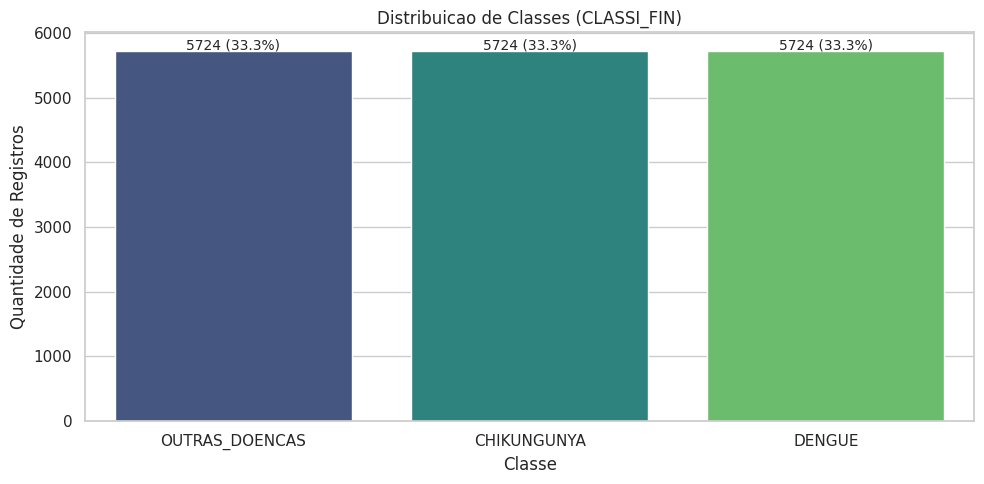

In [8]:
class_counts = df[TARGET_COL].value_counts().sort_index()
labels = [CLASS_NAME_MAP.get(i, str(i)) for i in class_counts.index]
ratios = (class_counts / class_counts.sum()) * 100

ax = sns.barplot(x=labels, y=class_counts.values, palette="viridis")
ax.set_title("Distribuicao de Classes (CLASSI_FIN)")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de Registros")

for idx, value in enumerate(class_counts.values):
    ax.text(idx, value + 20, f"{value} ({ratios.iloc[idx]:.1f}%)", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## STEP 4: Correlation Analysis

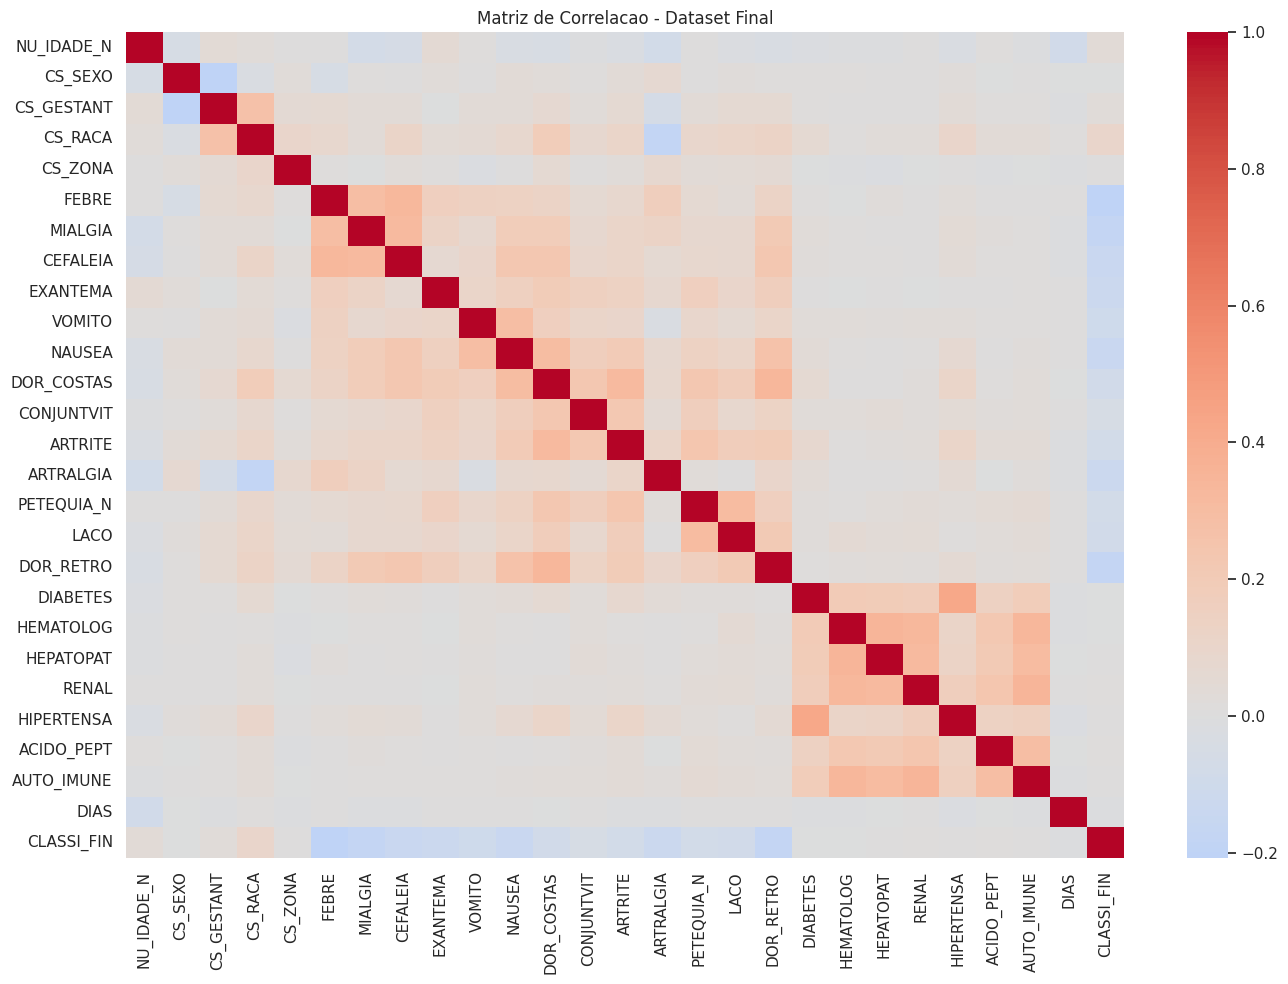

Top 10 atributos por correlacao absoluta com CLASSI_FIN:
FEBRE        0.208037
MIALGIA      0.178129
DOR_RETRO    0.176562
CEFALEIA     0.138663
NAUSEA       0.137674
ARTRALGIA    0.129551
EXANTEMA     0.126174
VOMITO       0.101229
CS_RACA      0.097150
LACO         0.089671
Name: CLASSI_FIN, dtype: float64


In [9]:
plt.figure(figsize=(14, 10))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, cmap="coolwarm", center=0)
plt.title("Matriz de Correlacao - Dataset Final")
plt.tight_layout()
plt.show()

# Correlacao absoluta com a classe alvo para apoio na analise.
abs_corr_target = correlation[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
print("Top 10 atributos por correlacao absoluta com CLASSI_FIN:")
print(abs_corr_target.head(10))

## STEP 5: Prepare Features and Target (with Feature Groups)

In [11]:
# Separamos atributos e alvo sem alterar valores do dataset.
columns_to_drop = ["CS_SEXO", "CS_GESTANT", "CS_RACA"]

X_df = df.drop(columns=[TARGET_COL]).copy()
X_df = X_df.drop(columns=columns_to_drop, errors="raise")
y = df[TARGET_COL].astype(int).values

classes = np.unique(y)
print("Detected classes:", classes)
if len(classes) != 3 or set(classes.tolist()) != {0, 1, 2}:
    raise ValueError("As classes esperadas para CLASSI_FIN sao exatamente 0, 1 e 2.")

print("Colunas removidas no Step 6:", columns_to_drop)

# Variaveis continuas conhecidas no dataset.
numeric_features = ["NU_IDADE_N", "DIAS"]

# Demais variaveis sao tratadas como categoricas codificadas.
categorical_features = [c for c in X_df.columns if c not in numeric_features]

print("X shape:", X_df.shape)
print("y shape:", y.shape)
print("Numericas:", numeric_features)
print("Quantidade de categoricas:", len(categorical_features))

Detected classes: [0 1 2]
Colunas removidas no Step 6: ['CS_SEXO', 'CS_GESTANT', 'CS_RACA']
X shape: (17172, 23)
y shape: (17172,)
Numericas: ['NU_IDADE_N', 'DIAS']
Quantidade de categoricas: 21


## STEP 6: Stratified Split, Preprocessing and Feature Selection

In [12]:
# Split estratificado para manter imparcialidade entre as classes.
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

# Verificacao explicita da proporcao de classes.
full_ratio = pd.Series(y).value_counts(normalize=True).sort_index()
train_ratio = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_ratio = pd.Series(y_test).value_counts(normalize=True).sort_index()
counts_df = pd.DataFrame(
    {
        "full_count": pd.Series(y).value_counts().sort_index(),
        "train_count": pd.Series(y_train).value_counts().sort_index(),
        "test_count": pd.Series(y_test).value_counts().sort_index(),
        "full_ratio": full_ratio,
        "train_ratio": train_ratio,
        "test_ratio": test_ratio,
    }
)
print("Distribuicao por classe apos split:")
display(counts_df)

# Preprocessamento misto: escala para continuas e one-hot para categoricas.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop",
)

X_train_prepared = preprocessor.fit_transform(X_train_df)
X_test_prepared = preprocessor.transform(X_test_df)

# 1) Remove features sem variancia.
variance_selector = VarianceThreshold(threshold=0.0)
X_train_var = variance_selector.fit_transform(X_train_prepared)
X_test_var = variance_selector.transform(X_test_prepared)

# 2) Seleciona melhores features por informacao mutua.
k_best = min(60, X_train_var.shape[1])
mi_selector = SelectKBest(score_func=mutual_info_classif, k=k_best)
X_train_selected = mi_selector.fit_transform(X_train_var, y_train)
X_test_selected = mi_selector.transform(X_test_var)

print("Features apos preprocessamento:", X_train_prepared.shape[1])
print("Features apos VarianceThreshold:", X_train_var.shape[1])
print("Features apos SelectKBest:", X_train_selected.shape[1])
print("X_train final:", X_train_selected.shape)
print("X_test final:", X_test_selected.shape)

Distribuicao por classe apos split:


,full_count,train_count,test_count,full_ratio,train_ratio,test_ratio
0,5724,4579,1145,0.333333,0.333333,0.333333
1,5724,4579,1145,0.333333,0.333333,0.333333
2,5724,4579,1145,0.333333,0.333333,0.333333


Features apos preprocessamento: 46
Features apos VarianceThreshold: 46
Features apos SelectKBest: 46
X_train final: (13737, 46)
X_test final: (3435, 46)


## STEP 7: Build and Compile Improved Multiclass Model

In [13]:
# Rede mais profunda com regularizacao para melhorar generalizacao.
model = tf.keras.Sequential([
    layers.Input(shape=(X_train_selected.shape[1],)),

    layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.20),

    layers.Dense(3, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

W0000 00:00:1775940316.265239   93065 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1775940316.412605   93065 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,915 (214.51 KB)

 Trainable params: 54,147 (211.51 KB)

 Non-trainable params: 768 (3.00 KB)

## STEP 8: Train Improved Model

In [14]:
# Callbacks para reduzir overfitting e ajustar taxa de aprendizado dinamicamente.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1,
)

history = model.fit(
    X_train_selected,
    y_train,
    epochs=120,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

Epoch 1/120


I0000 00:00:1775940318.363239  101718 service.cc:153] XLA service 0x7f345c036f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775940318.363273  101718 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.3.0)
I0000 00:00:1775940318.384313  101718 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775940318.511899  101718 cuda_dnn.cc:461] Loaded cuDNN version 90300
I0000 00:00:1775940318.561983  101718 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2840__.33
I0000 00:00:1775940318.837153  101796 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 4 bytes spill stores, 4 bytes spill loads



 92/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4642 - loss: 1.2814

I0000 00:00:1775940321.975961  101718 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


145/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4801 - loss: 1.2388

I0000 00:00:1775940322.433705  101717 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2840__.33
I0000 00:00:1775940323.031936  101717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.5198 - loss: 1.1224 - val_accuracy: 0.5702 - val_loss: 1.0186 - learning_rate: 0.0010
Epoch 2/120
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5551 - loss: 0.9908 - val_accuracy: 0.5844 - val_loss: 0.9535 - learning_rate: 0.0010
Epoch 3/120
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5795 - loss: 0.9540 - val_accuracy: 0.5986 - val_loss: 0.9315 - learning_rate: 0.0010
Epoch 4/120
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5871 - loss: 0.9398 - val_accuracy: 0.6001 - val_loss: 0.9198 - learning_rate: 0.0010
Epoch 5/120
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5897 - loss: 0.9270 - val_accuracy: 0.6117 - val_loss: 0.9186 - learning_rate: 0.0010
Epoch 6/120
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5991 - loss: 0.9213 - val_accuracy: 0.6055 - val_loss: 0.9200 - learning_rate: 0.0010
Epoch 7/120
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6022 - loss: 0.9188 - val

## STEP 9: Evaluate Accuracy and Advanced Metrics

I0000 00:00:1775940347.490432  101717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775940347.727878  104432 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1775940348.086192  101717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775940348.335172  104427 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 48 bytes spill stores, 48 bytes spill loads

I0000 00:00:1775940348.4853

Test loss: 0.9164
Test accuracy: 0.5939

Accuracy (sklearn): 0.5939
Balanced accuracy: 0.5939
Macro F1: 0.5828
Weighted F1: 0.5828


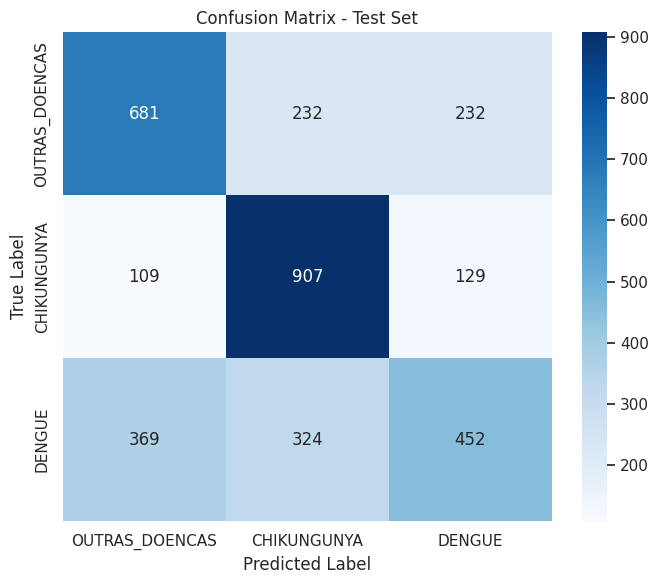


Classification Report:
                precision    recall  f1-score   support

OUTRAS_DOENCAS     0.5876    0.5948    0.5911      1145
   CHIKUNGUNYA     0.6200    0.7921    0.6956      1145
        DENGUE     0.5560    0.3948    0.4617      1145

      accuracy                         0.5939      3435
     macro avg     0.5878    0.5939    0.5828      3435
  weighted avg     0.5878    0.5939    0.5828      3435



In [15]:
test_loss, test_acc = model.evaluate(X_test_selected, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

probs = model.predict(X_test_selected, verbose=0)
y_pred = np.argmax(probs, axis=1)

acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("\nAccuracy (sklearn):", f"{acc:.4f}")
print("Balanced accuracy:", f"{bacc:.4f}")
print("Macro F1:", f"{macro_f1:.4f}")
print("Weighted F1:", f"{weighted_f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[CLASS_NAME_MAP[i] for i in sorted(CLASS_NAME_MAP)],
    yticklabels=[CLASS_NAME_MAP[i] for i in sorted(CLASS_NAME_MAP)],
)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[CLASS_NAME_MAP[i] for i in sorted(CLASS_NAME_MAP)],
        digits=4,
    )
)

## STEP 10: Training Curves (Loss and Accuracy)

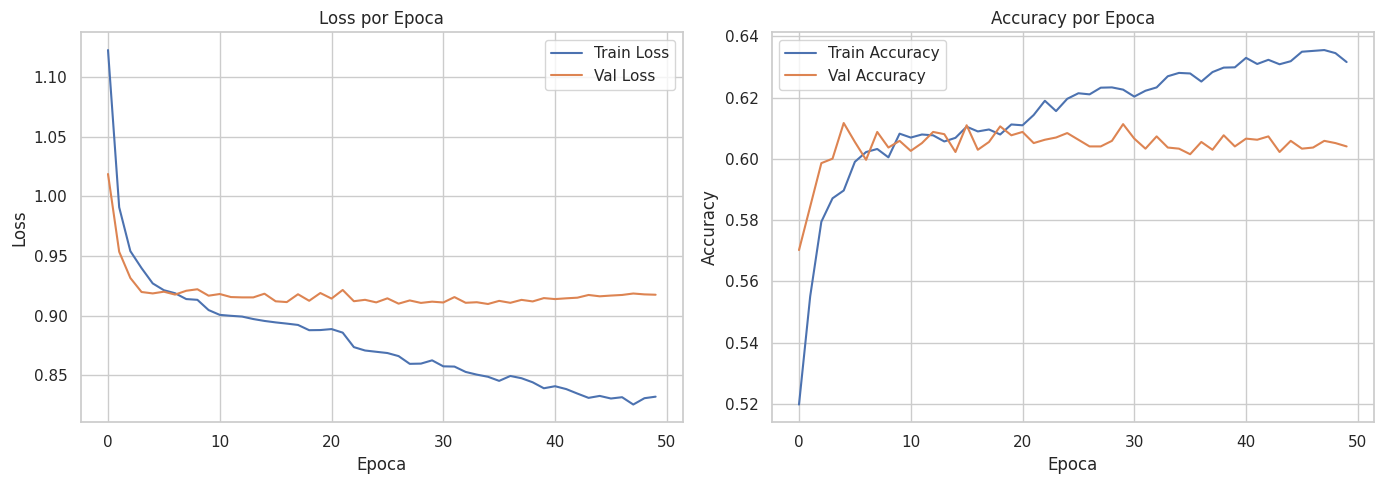

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss por Epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy por Epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()